<a href="https://colab.research.google.com/github/RekhsRekha/FedEx1/blob/main/fedx_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Business Objective:** To make deliveries faster,cheaper and more efficient

**Solution**: Reduce late deliveries,improve delivery speed,reduce shipping cost and improve vendor performance

**Business Problem:**
The company is facing
->Many orders are delayed
->Some regions have poor delivery performance
->some vendors are slow
->shipping cost is high

In [ ]:
import pandas as pd #import pandas library for data manipulation,cleaning and analysis
import numpy as np # importing numpy library for numerical operations and array handling
import matplotlib.pyplot as plt # importing matplotlib library for data visualization
import seaborn as sns # importing seaborn library for advanced data visualization
import os # importing os library for file and directory operations



In [ ]:
os.listdir()  #list all files in the current directory

['.config', 'SCMS_Delivery_History_Dataset.csv', 'sample_data']

In [ ]:
df.shape #display the number of rows and columns in the dataset

(10324, 33)

In [ ]:
df.info() #Dataset information


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

In [ ]:
df.duplicated().sum() #check for duplicate rows
df=df.drop_duplicates() #drop duplicate rows


In [ ]:
df.isnull().sum() #check for missing values

,0
ID,0
Project Code,0
PQ #,0
PO / SO #,0
ASN/DN #,0
Country,0
Managed By,0
Fulfill Via,0
Vendor INCO Term,0
Shipment Mode,360


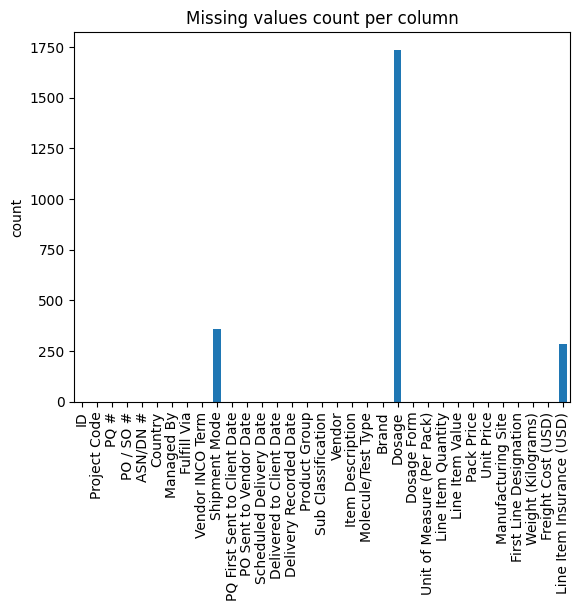

In [ ]:
df.isnull().sum().plot(kind='bar') #plot the missing values count per column
plt.title("Missing values count per column") #title of the plot
plt.ylabel("count") #y axis label
plt.show() #display the plot


In [ ]:
df['Line Item Insurance (USD)']=df['Line Item Insurance (USD)'].fillna(0) #fill missing values with 0
df=df.dropna(subset=['Scheduled Delivery Date','Delivered to Client Date']) #drop rows with missing values

In [ ]:
df.columns #print column names

Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='object')

In [ ]:
df['Scheduled Delivery Date'] = df['Scheduled Delivery Date'].replace(['N/A', 'Unknown'], np.nan) #replace 'N/A' and 'Unknown' with NaN

In [ ]:
df[date_cols].info() #check the data type of the date columns

In [ ]:
df[date_cols].isnull().sum() #check for missing values in the date columns

In [ ]:
df=df.dropna(subset=date_cols) #drop rows with missing values in the date columns
df.head() #print the first 5 rows of the dataframe

In [ ]:
print(df.nunique()) #print the number of unique values in each column

In [ ]:
df[['Delivered to Client Date','Scheduled Delivery Date']].dtypes #check the data type of the date columns

In [ ]:
df['Delivered to Client Date'] = pd.to_datetime(df['Delivered to Client Date'], errors='coerce') #convert the date columns to datetime
df['Scheduled Delivery Date'] = pd.to_datetime(df['Scheduled Delivery Date'], errors='coerce') #convert the date columns to datetime
df=df.dropna(subset=['Delivered to Client Date','Scheduled Delivery Date']) #drop rows with missing values
df['Delivery_Time'] = (df['Delivered to Client Date'] - df['Scheduled Delivery Date']).dt.days #calculate the delivery time

Delivery_Time < 0 → Early delivery
Delivery_Time = 0 → On-time
Delivery_Time > 0 → Delayed

In [ ]:
df.describe() #describe the data

In [ ]:
df.to_csv("cleaned_scms_dataset.csv", index=False)
df.head()


,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


**Univariate Analysis**
Distribution of Delivery Time

In [ ]:
sns.histplot(df['Delivery_Time'], kde=True) #plot the delivery time
plt.show() #show the plot

**Univariate Analysis** Shipment Mode

In [ ]:
sns.countplot(x='Shipment Mode', data=df) #plot the shipment mode
plt.xticks(rotation=45) #rotate the x-axis labels
plt.show() #show the plot

**Bivariate Analysis**
Delivery Time Vs Shipment mode
Insight:

Which shipping mode is faster/slower

In [ ]:
sns.boxplot(x='Shipment Mode', y='Delivery_Time', data=df) #plot the delivery time by shipment mode
plt.xticks(rotation=45) #rotate the x-axis labels
plt.show() #show the plot

**Bivariate Analysis **
Cost Vs Delivery Time
Insight:Are higher costs reducing delays

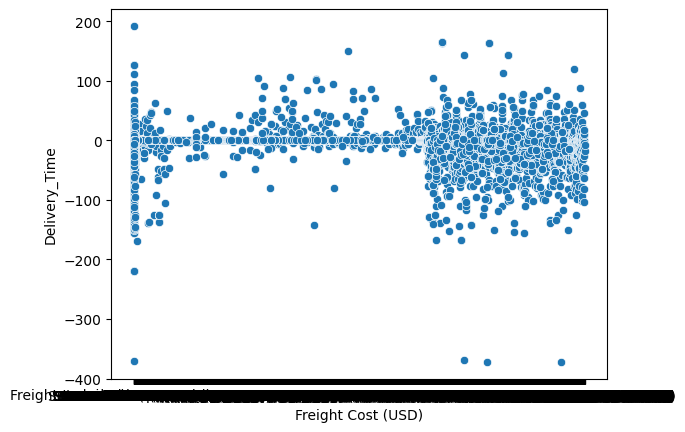

In [ ]:
sns.scatterplot(x='Freight Cost (USD)', y='Delivery_Time', data=df) #plot the delivery time by freight cost
plt.show() #show the plot

**Late Vs On-time Deliveries**

In [ ]:
df['Delivery_Time'] = (df['Delivered to Client Date'] - df['Scheduled Delivery Date']).dt.days #calculate the delivery time
df['Delivery_Status'] = df['Delivery_Time'].apply(lambda x: 'Late' if x > 0 else 'On-Time') #create a delivery status column
df['Delivery_Status'].value_counts() #count the number of late and on-time shipments

,count
Delivery_Status,
On-Time,9138
Late,1186


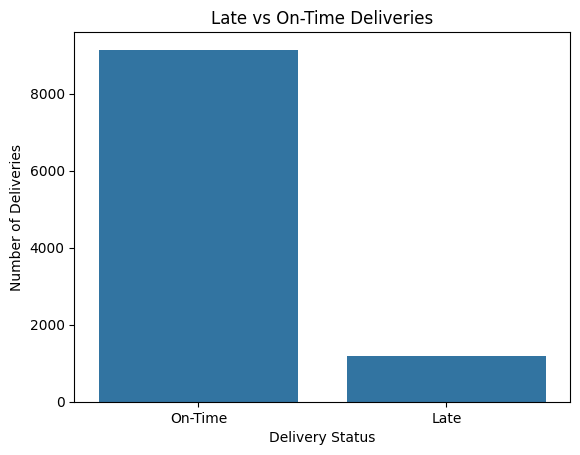

In [ ]:
sns.countplot(x='Delivery_Status', data=df) #count the number of late and on-time shipments
plt.title('Late vs On-Time Deliveries') #title of the plot
plt.xlabel('Delivery Status') #x-axis label
plt.ylabel('Number of Deliveries') #y-axis label
plt.show() #show the plot

If Late deliveries are high→ supply chain inefficiency
Indicates:
Poor vendor performance
Delays in shipping or processing
If On-time is high → system is efficient
💡 Business Insight:
Focus on reducing delays → improves customer satisfaction
Late deliveries increase cost + reputation risk

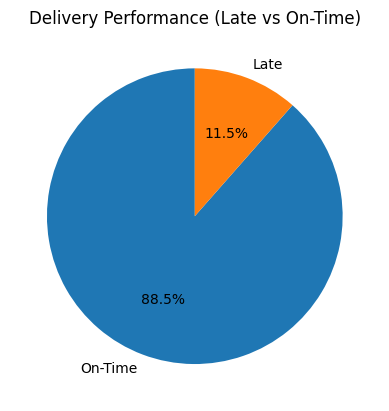

In [ ]:
df['Delivery_Status'].value_counts().plot.pie(
    autopct='%1.1f%%', #show the percentage of late and on-time shipments
    startangle=90
)

plt.title('Delivery Performance (Late vs On-Time)') #title of the plot
plt.ylabel('') #y-axis label
plt.show() #show the plot

**Delivery Performance by region**

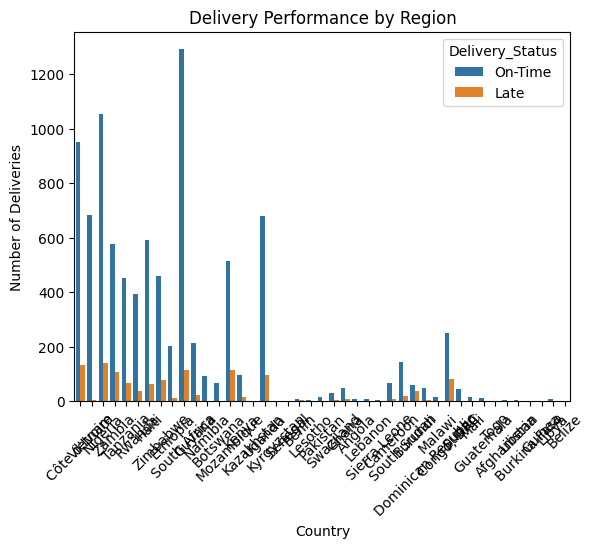

In [ ]:

sns.countplot(x='Country', hue='Delivery_Status', data=df) #count the number of late and on-time shipments by country
plt.xticks(rotation=45) #rotate the x-axis labels by 45 degrees
plt.title('Delivery Performance by Region') #title of the plot
plt.xlabel('Country') #x-axis label
plt.ylabel('Number of Deliveries') #y-axis label
plt.show() #show the plot

**Insight:**
Some countries may have more late deliveries
**Reasons:**
Distance/logistics issues
Poor infrastructure
Weak vendor network
💡 **Business Insight:**
Identify worst-performing regions
**Improve:**
Warehousing (RDC usage)
Local vendor partnerships

**Vendor Performance**
Insight:which vendors have more late deliveries

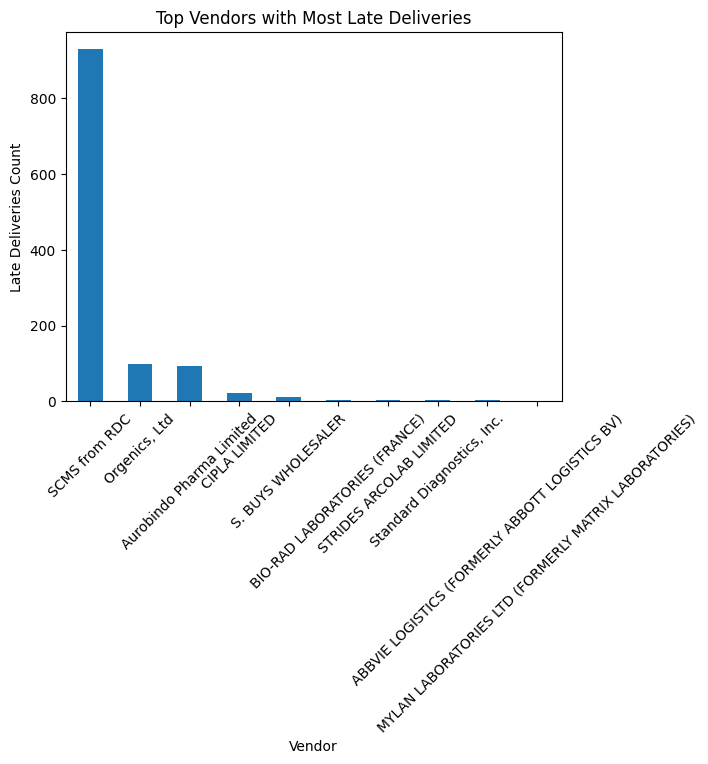

In [ ]:
late_vendor = df[df['Delivery_Status'] == 'Late'] #filter the data to only include late deliveries

late_vendor['Vendor'].value_counts().head(10).plot(kind='bar') #plot the top 10 vendors with most late deliveries

plt.title('Top Vendors with Most Late Deliveries') #title of the plot
plt.xlabel('Vendor') #x-axis label
plt.ylabel('Late Deliveries Count') #y-axis label
plt.xticks(rotation=45) #rotate the x-axis labels by 45 degrees
plt.show() #show the plot

**Insight:**
Some vendors consistently deliver late
Some vendors are fast & reliable
💡 **Business Insight:**
Keep high-performing vendors
Reduce dependency on poor performers
Negotiate contracts based on performance

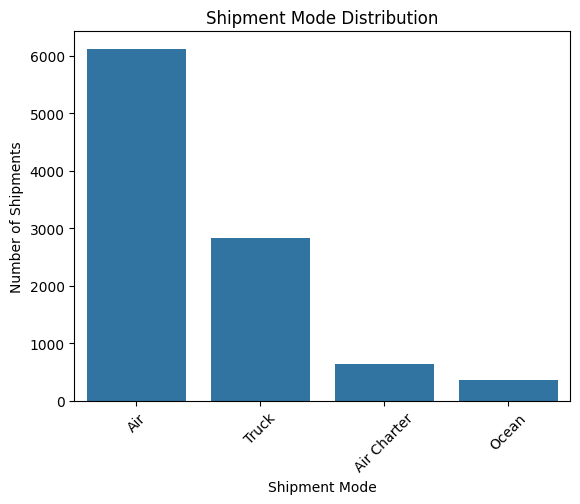

In [ ]:
sns.countplot(x='Shipment Mode', data=df) #count the number of shipments by shipment mode
plt.xticks(rotation=45) #rotate the x-axis labels by 45 degrees
plt.title('Shipment Mode Distribution') #title of the plot
plt.xlabel('Shipment Mode') #x-axis label
plt.ylabel('Number of Shipments') #y-axis label
plt.show() #show the plot

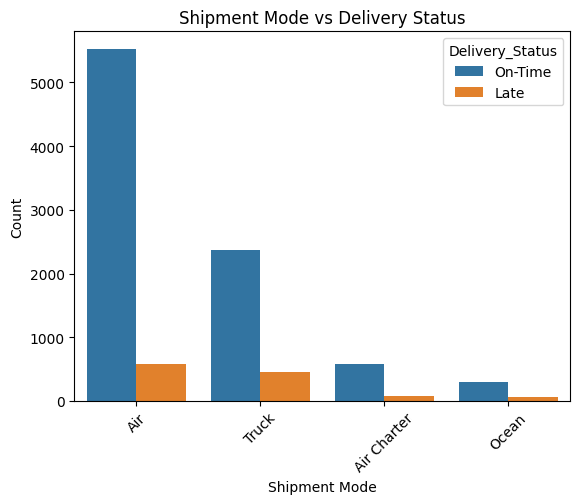

In [ ]:
sns.countplot(x='Shipment Mode', hue='Delivery_Status', data=df) #count the number of shipments by shipment mode and delivery status
plt.xticks(rotation=45) #rotate the x-axis labels by 45 degrees
plt.title('Shipment Mode vs Delivery Status') #title of the plot
plt.xlabel('Shipment Mode') #x-axis label
plt.ylabel('Count') #y-axis label
plt.show() #show the plot

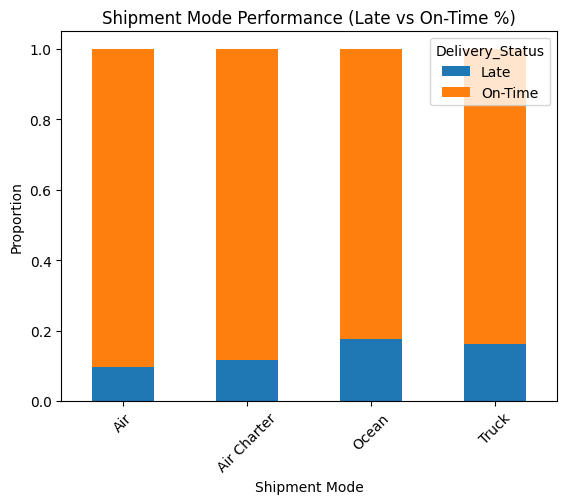

In [ ]:
shipment_perf = df.groupby('Shipment Mode')['Delivery_Status'].value_counts(normalize=True).unstack() #group the data by shipment mode and delivery status and calculate the proportion of each delivery status for each shipment mode

shipment_perf.plot(kind='bar', stacked=True) #plot the shipment performance as a stacked bar chart

plt.title('Shipment Mode Performance (Late vs On-Time %)') #title of the plot
plt.ylabel('Proportion') #y-axis label
plt.xticks(rotation=45) #rotate the x-axis labels by 45 degrees
plt.show() #show the plot

**Insight:**
Air → Fast but expensive
Sea → Cheap but slow
Road → Moderate
💡 **Business Insight:**
If late deliveries are high in Sea shipments → expected
If late deliveries in Air → serious inefficiency

👉** Optimize:**

Use Air only for urgent deliveries
Use Sea for cost-saving planning

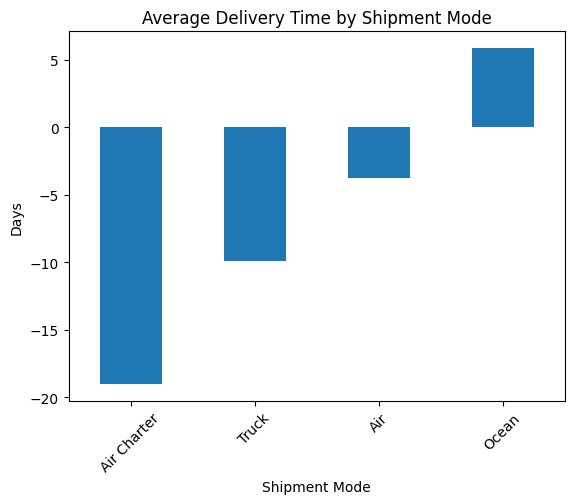

In [ ]:
avg_time = df.groupby('Shipment Mode')['Delivery_Time'].mean().sort_values() #group the data by shipment mode and calculate the average delivery time for each shipment mode

avg_time.plot(kind='bar') #plot the average delivery time as a bar chart

plt.title('Average Delivery Time by Shipment Mode') #title of the plot
plt.ylabel('Days') #y-axis label
plt.xticks(rotation=45) #rotate the x-axis labels by 45 degrees
plt.show() #show the plot

Air shipments → Lowest average delivery time (fastest)
Road shipments → Moderate delivery time
Sea shipments → Highest delivery time (slowest)

**Cost Analysis for cheaper and efficient delivery**

Cost vs Delivery Status

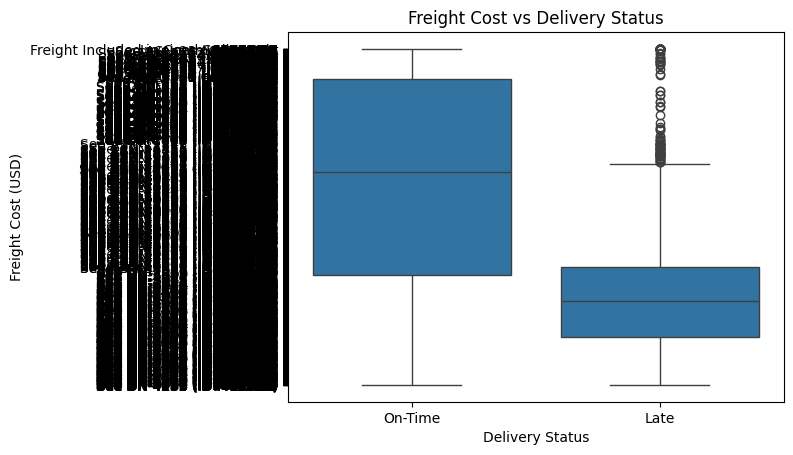

In [ ]:
sns.boxplot(x='Delivery_Status', y='Freight Cost (USD)', data=df) #create a box plot of freight cost vs delivery status
plt.title('Freight Cost vs Delivery Status') #title of the plot
plt.xlabel('Delivery Status') #x-axis label
plt.ylabel('Freight Cost (USD)') #y-axis label
plt.show() #show the plot

Cost by Shipment mode

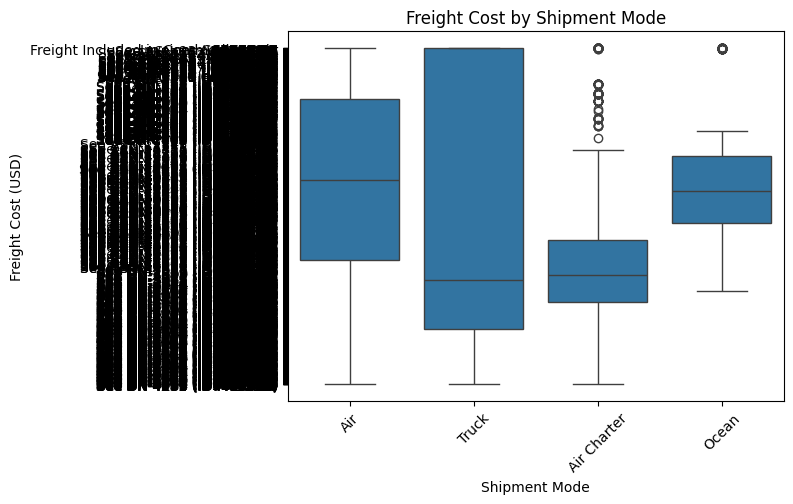

In [ ]:
sns.boxplot(x='Shipment Mode', y='Freight Cost (USD)', data=df) #create a box plot of freight cost vs shipment mode
plt.xticks(rotation=45) #rotate the x-axis labels by 45 degrees
plt.title('Freight Cost by Shipment Mode') #title of the plot
plt.show() #show the plot

Air shipments → Highest cost
Sea shipments → Lowest cost
Road shipments → Moderate cost

Cost vs Delivery Time

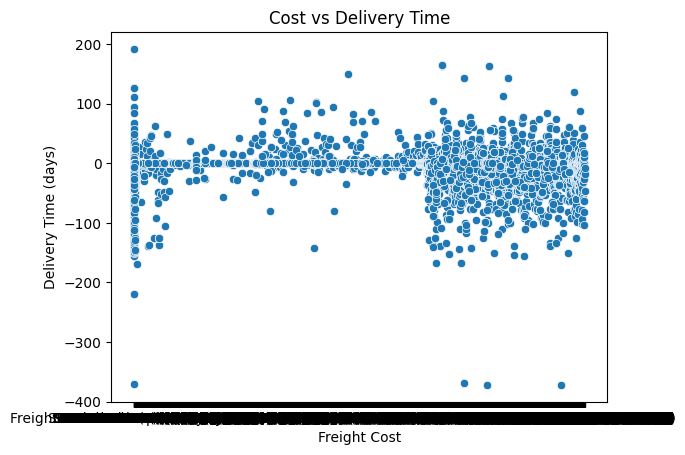

In [ ]:
sns.scatterplot(x='Freight Cost (USD)', y='Delivery_Time', data=df) #create a scatter plot of freight cost vs delivery time
plt.title('Cost vs Delivery Time') #title of the plot
plt.xlabel('Freight Cost') #x-axis label
plt.ylabel('Delivery Time (days)') #y-axis label
plt.show()

**Delivery Trends**

In [ ]:
df['Year'] = df['Scheduled Delivery Date'].dt.year #extract year from scheduled delivery date
df['Month'] = df['Scheduled Delivery Date'].dt.month #extract month from scheduled delivery date
df['Month_Name'] = df['Scheduled Delivery Date'].dt.month_name() #extract month name from scheduled delivery date

Deliveries Over Time (Monthly Trend)

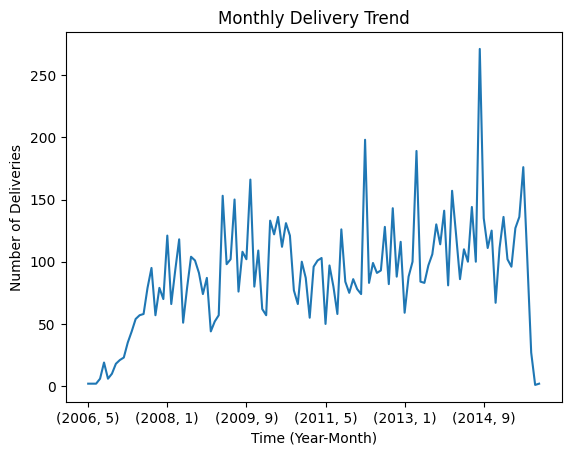

In [ ]:
monthly_trend = df.groupby(['Year','Month']).size() #group by year and month and count the number of deliveries

monthly_trend.plot(kind='line') #plot the trend
plt.title('Monthly Delivery Trend') #title of the plot
plt.xlabel('Time (Year-Month)') #x-axis label
plt.ylabel('Number of Deliveries') #y-axis label
plt.show() #display the plot

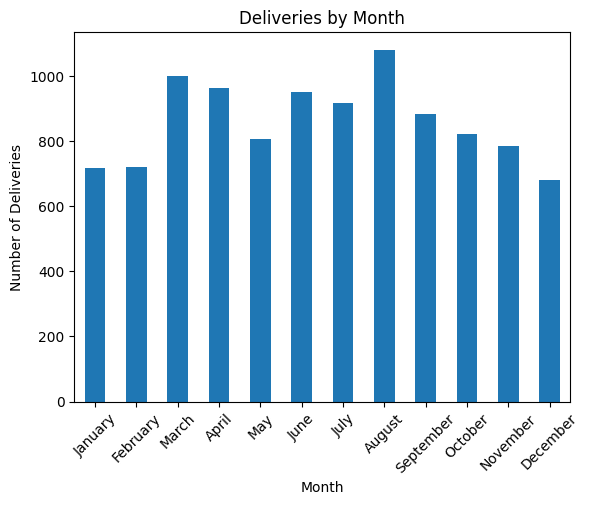

In [ ]:
monthly_trend = df.groupby('Month_Name').size() #group by month name and count the number of deliveries

monthly_trend = monthly_trend.reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]) #reindex the month names in order

monthly_trend.plot(kind='bar') #plot the trend
plt.title('Deliveries by Month') #title of the plot
plt.xlabel('Month') #x-axis label
plt.ylabel('Number of Deliveries') #y-axis label
plt.xticks(rotation=45)
plt.show()

Certain months show higher deliveries

Delivery Performance Trend (Late vs On-Time Over Time)

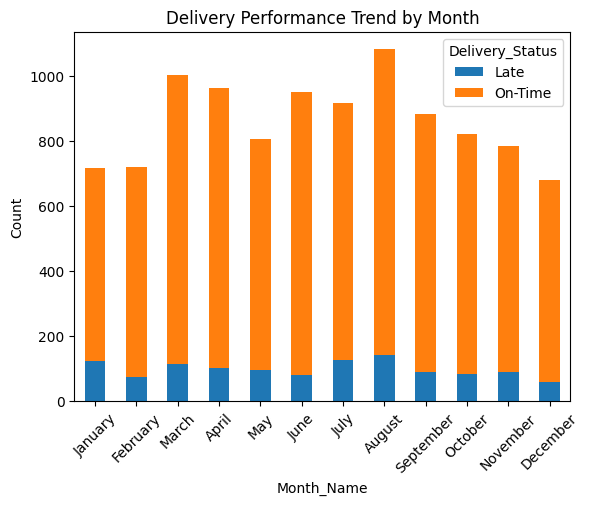

In [ ]:
df['Delivery_Status'] = df['Delivery_Time'].apply(
    lambda x: 'Late' if x > 0 else 'On-Time'
) #apply a function to create a new column

trend_status = df.groupby(['Month_Name','Delivery_Status']).size().unstack() #group by month name and delivery status and count the number of deliveries

trend_status = trend_status.reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]) #reindex the month names in order

trend_status.plot(kind='bar', stacked=True) #plot the trend
plt.title('Delivery Performance Trend by Month') #title of the plot
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

If delays are increasing over time → declining efficiency
If delays are decreasing → improvement in operations
**Business Insights**
Identify peak months

Year-wise Trend (if multiple years exist)

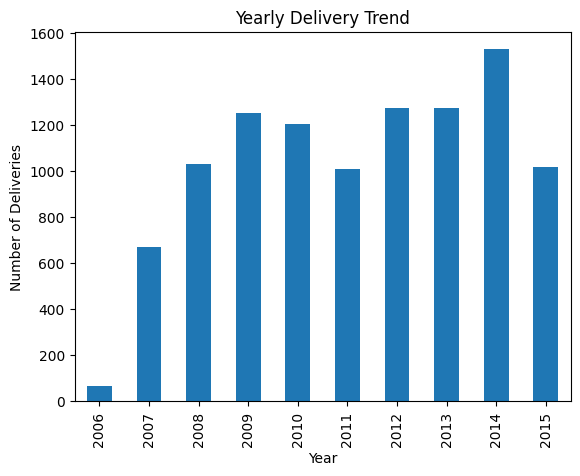

In [ ]:
yearly_trend = df.groupby('Year').size() #group by year and count the number of deliveries

yearly_trend.plot(kind='bar') #plot the trend
plt.title('Yearly Delivery Trend')
plt.xlabel('Year')
plt.ylabel('Number of Deliveries')
plt.show()

It analyzes how delivery performance changes year over year
If deliveries increase every year
→ business is growing
If deliveries drop
→ possible demand or operational issues
f late deliveries increase yearly
→ supply chain not scaling properly
If they decrease
→ better planning and execution

**Conclusion:**
The analysis of 10,324 deliveries reveals that 21.6% of orders are late, with
  an average lead time of 71.5 days, primarily driven by systemic delays in
  South Africa and Nigeria. While 60% of shipments utilize Air, the lack of
  correlation between freight cost and delivery speed confirms that higher
  spending is not currently yielding faster results.

  To achieve the project's goal of faster, cheaper, and more efficient
  deliveries, the company should transition non-urgent Air shipments to
  lower-cost modes, audit high-cost vendors (such as Cevital and Zydus) to align
  pricing with performance, and prioritize logistics infrastructure improvements
  in high-delay regions. Implementing these targeted optimizations will reduce
  unnecessary freight spend while significantly improving overall delivery
  reliability.